In [1]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from utils import *
data_path = "/jukebox/falkner/Jorge/Dexter_results/all_obs_xpo_pred_dict_v2_102325.pkl"
with open(data_path, "rb") as f:
    data_dict = pickle.load(f)

setup_plot_style()

In [2]:
mouse_id_list = list(data_dict.keys())[: -1] # get rid of the familiar vs novel first
categories_count_mtx = np.zeros((len(mouse_id_list), 8, 4))

for idx, mouse_id in enumerate(mouse_id_list):
    pred_full = data_dict[mouse_id]
    
    for d_idx in np.arange(categories_count_mtx.shape[1]):
        pred_full_d_s = pred_full[(pred_full["day_id"] == d_idx + 1)]
        categories_count = (pred_full_d_s["prediction"].apply(label_to_categories).value_counts() / len(pred_full_d_s)).to_dict()
        for uniq_category in np.arange(1, 5):
            categories_count_mtx[idx, d_idx, uniq_category - 1] = categories_count.get(uniq_category, 0)

Linear regression analysis for behavioral categories across days:
Attention:
  Slope: 0.015646
  P-value: 0.045120
  R-squared: 0.514728
  Significance: *

Self-directed:
  Slope: -0.001106
  P-value: 0.852630
  R-squared: 0.006229
  Significance: ns

Idle:
  Slope: -0.013040
  P-value: 0.077388
  R-squared: 0.430187
  Significance: ns

Exploratory:
  Slope: -0.001500
  P-value: 0.597370
  R-squared: 0.049246
  Significance: ns



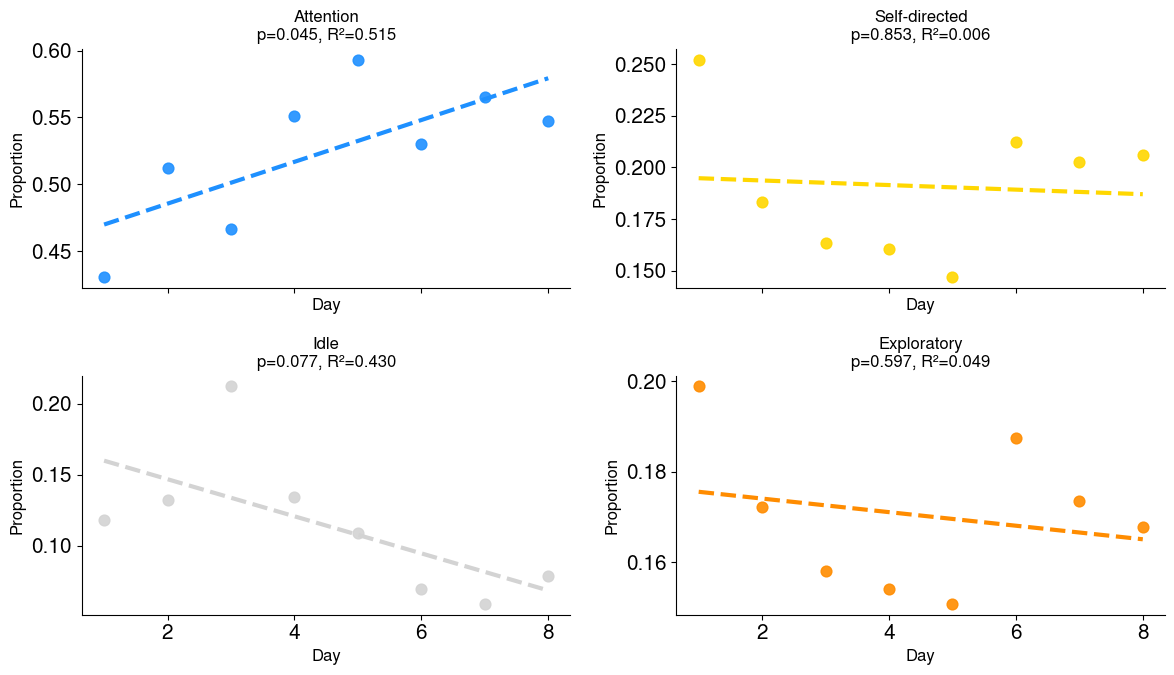

In [3]:
from scipy import stats

colors = ["dodgerblue", "gold", "lightgray", "darkorange"]  # Different colors for each category

# Linear regression analysis for each behavioral category
print("Linear regression analysis for behavioral categories across days:")
print("=" * 60)

# Create figure for plotting
fig, axs = plt.subplots(ncols = 2, nrows = 2, figsize = (12, 7), sharex = True)
for beh_idx in range(categories_count_mtx.shape[2]):
    # Get mean proportion across days for this behavior
    mean_props = categories_count_mtx[:, :, beh_idx].mean(axis=0)
    days = np.arange(1, len(mean_props) + 1)
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(days, mean_props)
    
    print(f"{categories_label_dict[beh_idx + 1]}:")
    print(f"  Slope: {slope:.6f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  R-squared: {r_value**2:.6f}")
    print(f"  Significance: {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
    print()
    
    # Plot the data and regression line
    axs[beh_idx // 2, beh_idx % 2].scatter(days, mean_props, color=colors[beh_idx], s=60, alpha=0.9, label='Data')
    
    # Plot regression line
    regression_line = slope * days + intercept
    axs[beh_idx // 2, beh_idx % 2].plot(days, regression_line, color=colors[beh_idx], linestyle='--', linewidth=3)
    
    axs[beh_idx // 2, beh_idx % 2].set_xlabel('Day', fontsize=12)
    axs[beh_idx // 2, beh_idx % 2].set_ylabel('Proportion', fontsize=12)
    axs[beh_idx // 2, beh_idx % 2].set_title(f'{categories_label_dict[beh_idx + 1]}\np={p_value:.3f}, R²={r_value**2:.3f}', fontsize=12)

plt.tight_layout()
sns.despine()
# plt.savefig("/usr/people/tt1131/projects/social_dojo_observer/fig/behavioral_categories_regression_analysis.png", dpi=300)
plt.show()

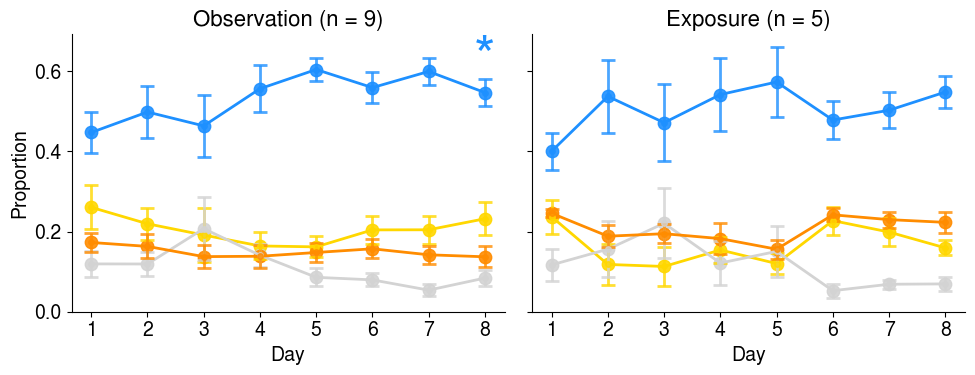

In [8]:
fig, axs = plt.subplots(ncols = 2, figsize = (10, 4), sharey = True, sharex = True)

obs_indices = np.where(np.array(list(label_to_cond_dict.values())) == "obs")[0]
xpo_indices = np.where(np.array(list(label_to_cond_dict.values())) == "xpo")[0]

for beh_idx in np.arange(4):
    se_shade_obs = categories_count_mtx[obs_indices, :, beh_idx].std(axis = 0) / np.sqrt(len(obs_indices))
    se_shade_xpo = categories_count_mtx[xpo_indices, :, beh_idx].std(axis = 0) / np.sqrt(len(xpo_indices))
    
    mean_obs = categories_count_mtx[obs_indices, :, beh_idx].mean(axis = 0)
    mean_xpo = categories_count_mtx[xpo_indices, :, beh_idx].mean(axis = 0)
    
    days = np.arange(categories_count_mtx.shape[1])
    
    axs[0].scatter(days, mean_obs, color = colors[beh_idx], label = "obs", s=80, alpha=0.9)
    axs[1].scatter(days, mean_xpo, color = colors[beh_idx], label = "xpo", s=80, alpha=0.9)
    axs[0].plot(days, mean_obs, color = colors[beh_idx], label = "obs", lw = 2)
    axs[1].plot(days, mean_xpo, color = colors[beh_idx], label = "xpo", lw = 2)
    axs[0].errorbar(days, mean_obs, yerr=se_shade_obs, color = colors[beh_idx], 
                   fmt='o', markersize=4, capsize=5, capthick=2, elinewidth=2, alpha=0.8)
    axs[1].errorbar(days, mean_xpo, yerr=se_shade_xpo, color = colors[beh_idx], 
                   fmt='o', markersize=4, capsize=5, capthick=2, elinewidth=2, alpha=0.8)
    
    if beh_idx == 0:
        x_lr_ticks = np.arange(-.25, len(days) - .25, .25)
        # Perform linear regression for obs condition
        slope_obs, intercept_obs, r_value_obs, p_value_obs, std_err_obs = stats.linregress(days, mean_obs)
        regression_line_obs = slope_obs * x_lr_ticks + intercept_obs
        # axs[0].plot(x_lr_ticks, regression_line_obs, color=colors[beh_idx], linestyle='--', linewidth=3, alpha=0.8)
        
        # Perform linear regression for xpo condition
        slope_xpo, intercept_xpo, r_value_xpo, p_value_xpo, std_err_xpo = stats.linregress(days, mean_xpo)
        regression_line_xpo = slope_xpo * x_lr_ticks + intercept_xpo
        # axs[1].plot(x_lr_ticks, regression_line_xpo, color=colors[beh_idx], linestyle='--', linewidth=3, alpha=0.8)
        
        # Add significance stars if p-value is significant
        max_x_pos = 7
        if p_value_obs < 0.05:
            stars_obs = '***' if p_value_obs < 0.001 else '**' if p_value_obs < 0.01 else '*'
            # Find the highest point on the regression line to place the star
            max_y_obs = max(regression_line_obs) - .05
            axs[0].text(max_x_pos, max_y_obs, stars_obs, fontsize=40, 
                        ha='center', va='bottom', color=colors[beh_idx])
        
        if p_value_xpo < 0.05:
            stars_xpo = '***' if p_value_xpo < 0.001 else '**' if p_value_xpo < 0.01 else '*'
            # Find the highest point on the regression line to place the star
            max_y_xpo = max(regression_line_xpo) - .05
            axs[1].text(max_x_pos, max_y_xpo, stars_xpo, fontsize=40, 
                        ha='center', va='bottom', color=colors[beh_idx])
    
    
font_size = 14
axs[0].set_xlabel("Day", fontsize = font_size)
axs[1].set_xlabel("Day", fontsize = font_size)
axs[0].set_ylabel("Proportion", fontsize = font_size)
axs[0].set_xticks(np.arange(0, 8, 1), np.arange(1, 9, 1), fontsize = font_size)
axs[1].set_xticks(np.arange(0, 8, 1), np.arange(1, 9, 1), fontsize = font_size)
axs[0].set_yticks(np.arange(0, .8, 0.2), np.round(np.arange(0, .8, 0.2), 2), fontsize = font_size)
axs[1].set_yticks(np.arange(0, .8, 0.2), np.round(np.arange(0, .8, 0.2), 2), fontsize = font_size)
    
axs[0].set_title(f"Observation (n = {len(obs_indices)})", fontsize = font_size + 2)
axs[1].set_title(f"Exposure (n = {len(xpo_indices)})", fontsize = font_size + 2)
    
plt.tight_layout()
sns.despine()

# plt.savefig("/usr/people/tt1131/projects/social_dojo_observer/fig/pub/behavioral_categories_distribution_across_days_obs_xpo.svg", format = "svg")

In [9]:
import statsmodels.formula.api as smf
def run_lme_analysis(categories_count_mtx, indices, condition_name, beh_idx=0):
    """
    Run linear mixed effects model on individual-level data.
    
    Parameters
    ----------
    categories_count_mtx : array, shape (n_individuals, n_days, n_behaviors)
    indices : array of indices for this condition
    condition_name : str
    beh_idx : int, behavior index
    
    Returns
    -------
    result : statsmodels MixedLMResults
    """
    # Build long-format dataframe with individual-level data
    records = []
    for i, ind_idx in enumerate(indices):
        for day in range(categories_count_mtx.shape[1]):
            records.append({
                'individual': i,
                'day': day,
                'proportion': categories_count_mtx[ind_idx, day, beh_idx]
            })
    
    df = pd.DataFrame(records)
    
    # Fit LME with random intercept per individual
    model = smf.mixedlm("proportion ~ day", data=df, groups=df["individual"])
    result = model.fit()
    
    return result, df

# Run for both conditions
result_obs, df_obs = run_lme_analysis(categories_count_mtx, obs_indices, "obs", beh_idx=0)
result_xpo, df_xpo = run_lme_analysis(categories_count_mtx, xpo_indices, "xpo", beh_idx=0)

# Extract p-value for the day effect
p_value_obs_lme = result_obs.pvalues['day']
p_value_xpo_lme = result_xpo.pvalues['day']

print(f"OBS - Day effect: β={result_obs.params['day']:.4f}, p={p_value_obs_lme:.4f}")
print(f"XPO - Day effect: β={result_xpo.params['day']:.4f}, p={p_value_xpo_lme:.4f}")

OBS - Day effect: β=0.0183, p=0.0021
XPO - Day effect: β=0.0109, p=0.2286


LME Results for behavior 0:
  OBS: β(day)=0.0183, p=0.0021 **
  XPO: β(day)=0.0109, p=0.2286 


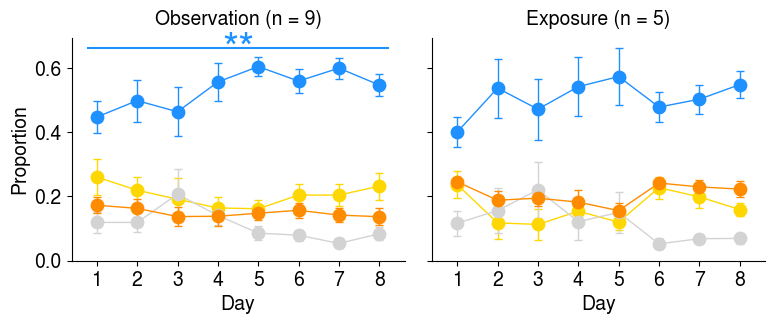

In [10]:
def run_lme_analysis(categories_count_mtx, indices, beh_idx=0):
    """
    Run linear mixed effects model on individual-level data.
    """
    records = []
    for i, ind_idx in enumerate(indices):
        for day in range(categories_count_mtx.shape[1]):
            records.append({
                'individual': i,
                'day': day,
                'proportion': categories_count_mtx[ind_idx, day, beh_idx]
            })
    
    df = pd.DataFrame(records)
    model = smf.mixedlm("proportion ~ day", data=df, groups=df["individual"])
    result = model.fit()
    
    return result, df

def get_significance_stars(p_value):
    """Convert p-value to significance stars."""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''


def plot_behavior_proportions_with_lme(categories_count_mtx, label_to_cond_dict, colors,
                                        test_beh_idx=0, figsize=(10, 4), fig_path=None, fontsize=14):
    """
    Plot behavior proportions across days with LME statistics.
    
    Parameters
    ----------
    categories_count_mtx : array, shape (n_individuals, n_days, n_behaviors)
    label_to_cond_dict : dict mapping labels to conditions
    colors : list of colors for each behavior
    test_beh_idx : int, behavior index to run LME on
    figsize : tuple
    """
    fig, axs = plt.subplots(ncols=2, figsize=figsize, sharey=True, sharex=True)
    
    obs_indices = np.where(np.array(list(label_to_cond_dict.values())) == "obs")[0]
    xpo_indices = np.where(np.array(list(label_to_cond_dict.values())) == "xpo")[0]
    
    n_days = categories_count_mtx.shape[1]
    days = np.arange(n_days)
    
    # Run LME for the target behavior
    result_obs, _ = run_lme_analysis(categories_count_mtx, obs_indices, beh_idx=test_beh_idx)
    result_xpo, _ = run_lme_analysis(categories_count_mtx, xpo_indices, beh_idx=test_beh_idx)
    
    p_value_obs = result_obs.pvalues['day']
    p_value_xpo = result_xpo.pvalues['day']
    
    # Store y-max for positioning significance annotations
    y_max_obs = 0
    y_max_xpo = 0
    
    # Plot all behaviors
    for beh_idx in np.arange(categories_count_mtx.shape[2]):
        se_obs = categories_count_mtx[obs_indices, :, beh_idx].std(axis=0) / np.sqrt(len(obs_indices))
        se_xpo = categories_count_mtx[xpo_indices, :, beh_idx].std(axis=0) / np.sqrt(len(xpo_indices))
        
        mean_obs = categories_count_mtx[obs_indices, :, beh_idx].mean(axis=0)
        mean_xpo = categories_count_mtx[xpo_indices, :, beh_idx].mean(axis=0)
        
        # Track max for annotation positioning
        if beh_idx == test_beh_idx:
            y_max_obs = (mean_obs + se_obs).max()
            y_max_xpo = (mean_xpo + se_xpo).max()
        
        # Plot lines and points
        axs[0].plot(days, mean_obs, color=colors[beh_idx], lw=1)
        axs[1].plot(days, mean_xpo, color=colors[beh_idx], lw=1)
        axs[0].scatter(days, mean_obs, color=colors[beh_idx], s=80, alpha=1, zorder=3)
        axs[1].scatter(days, mean_xpo, color=colors[beh_idx], s=80, alpha=1, zorder=3)
        
        # Error bars
        axs[0].errorbar(days, mean_obs, yerr=se_obs, color=colors[beh_idx], markersize = 7,
                        fmt='none', capsize=3, capthick=1, elinewidth=1, alpha=1)
        axs[1].errorbar(days, mean_xpo, yerr=se_xpo, color=colors[beh_idx], markersize = 7,
                        fmt='none', capsize=3, capthick=1, elinewidth=1, alpha=1)

    # Add significance annotations
    line_y_offset = 0.03
    star_y_offset = -0.075
    
    for ax, p_value, y_max, condition in [(axs[0], p_value_obs, y_max_obs, 'obs'),
                                           (axs[1], p_value_xpo, y_max_xpo, 'xpo')]:
        stars = get_significance_stars(p_value)
        if stars:
            line_y = y_max + line_y_offset
            
            # Draw horizontal line spanning effect duration (day 1-8, i.e., indices 0-7)
            ax.hlines(y=line_y, xmin=-.25, xmax=n_days - .75, 
                      color=colors[test_beh_idx], linewidth=1.5, linestyle='-')
            
            ax.text((n_days - 1) / 2, line_y + star_y_offset, stars,
                    fontsize=30, ha='center', va='bottom', color=colors[test_beh_idx])
    
    # Formatting
    axs[0].set_xlabel("Day", fontsize=font_size)
    axs[1].set_xlabel("Day", fontsize=font_size)
    axs[0].set_ylabel("Proportion", fontsize=font_size)
    
    axs[0].set_xticks(days, days + 1, fontsize=font_size)
    axs[1].set_xticks(days, days + 1, fontsize=font_size)
    axs[0].set_yticks(np.arange(0, 0.8, 0.2), np.round(np.arange(0, 0.8, 0.2), 2), fontsize=font_size)
    
    axs[0].set_title(f"Observation (n = {len(obs_indices)})", fontsize=font_size , y = 1.02)
    axs[1].set_title(f"Exposure (n = {len(xpo_indices)})", fontsize=font_size, y = 1.02)
    
    plt.tight_layout()
    sns.despine()
    
    # Print LME results
    print(f"LME Results for behavior {test_beh_idx}:")
    print(f"  OBS: β(day)={result_obs.params['day']:.4f}, p={p_value_obs:.4f} {get_significance_stars(p_value_obs)}")
    print(f"  XPO: β(day)={result_xpo.params['day']:.4f}, p={p_value_xpo:.4f} {get_significance_stars(p_value_xpo)}")
    
    if fig_path is not None:
        plt.savefig(fig_path, format = "svg")
    
    return fig, axs, {'obs': result_obs, 'xpo': result_xpo}


fig_path = "/usr/people/tt1131/projects/social_dojo_observer/fig/pub/behavioral_categories_distribution_across_days_obs_xpo.svg"
fig, axs, lme_results = plot_behavior_proportions_with_lme(
    categories_count_mtx, 
    label_to_cond_dict, 
    colors,
    test_beh_idx=0,
    figsize=(8, 3.5),
    fig_path=fig_path,
    fontsize=12
)